In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('Iris.csv')
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [ ]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Frequency')

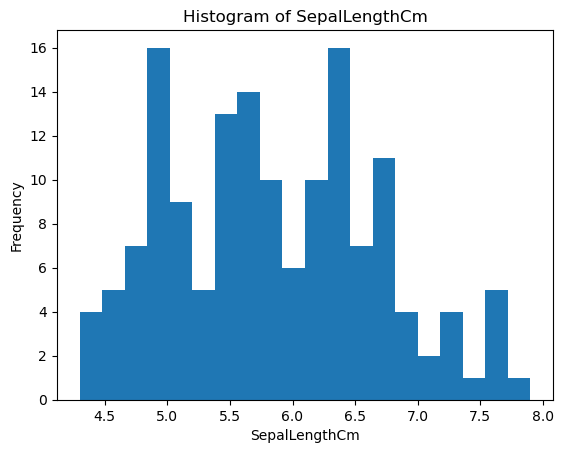

In [ ]:
plt.hist(df['SepalLengthCm'], bins=20)
plt.title(f'Histogram of SepalLengthCm')
plt.xlabel('SepalLengthCm')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

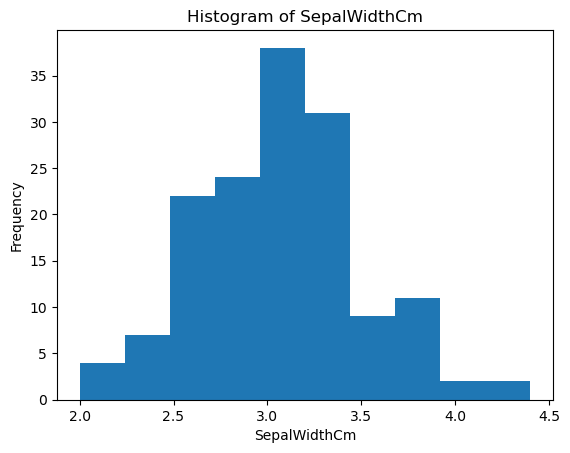

In [ ]:
plt.hist(df['SepalWidthCm'], bins=10) # Adjust the number of bins as needed
plt.title(f'Histogram of SepalWidthCm')
plt.xlabel('SepalWidthCm')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

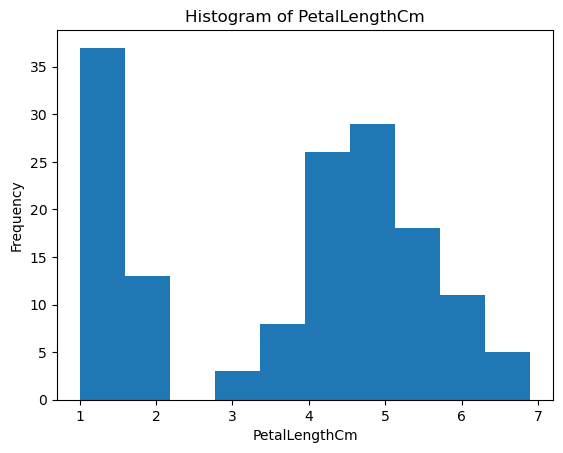

In [ ]:
plt.hist(df['PetalLengthCm'], bins=10)
plt.title(f'Histogram of PetalLengthCm')
plt.xlabel('PetalLengthCm')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

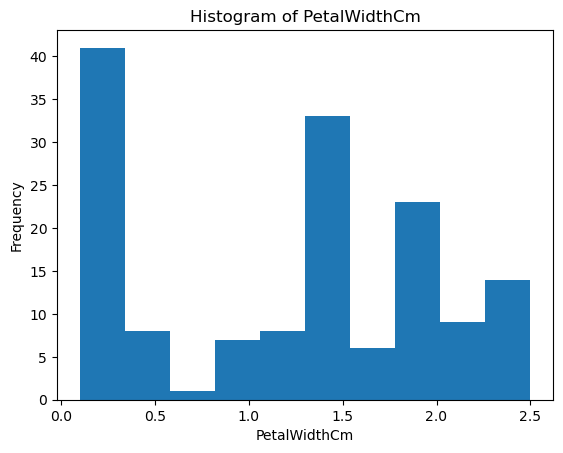

In [ ]:
plt.hist(df['PetalWidthCm'], bins=10)
plt.title(f'Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')

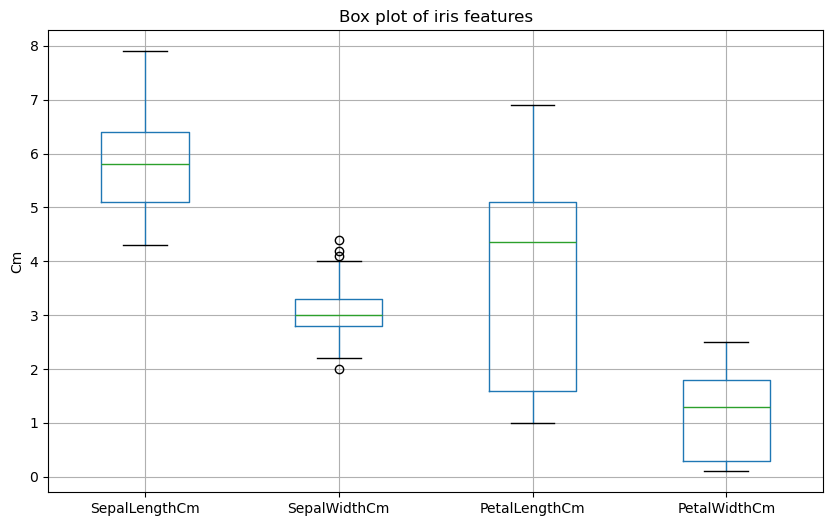

In [ ]:
plt.figure(figsize=(10, 6))
df.boxplot(column=['SepalLengthCm','SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])
plt.title('Box plot of iris features')
plt.ylabel('Cm')
plt.show()

In [ ]:
Q1=df['SepalWidthCm'].quantile(0.25)
Q3=df['SepalWidthCm'].quantile(0.75)
IQR=Q3-Q1

In [ ]:
lower_bound=Q1 - 1.5* IQR
upper_bound=Q3 + 1.5* IQR

In [ ]:
lower_bound

2.05

In [ ]:
upper_bound

4.05

In [ ]:
outliers=df[(df['SepalWidthCm'] < lower_bound) | (df['SepalWidthCm'] > upper_bound)]
print("Outliers in SepalWidthCm:")
outliers

Outliers in SepalWidthCm:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
15,16,5.7,4.4,1.5,0.4,Iris-setosa
32,33,5.2,4.1,1.5,0.1,Iris-setosa
33,34,5.5,4.2,1.4,0.2,Iris-setosa
60,61,5.0,2.0,3.5,1.0,Iris-versicolor


In [ ]:
outliers_indices = outliers.index
print("Outliers RowIndex:")
outliers_indices

Outliers RowIndex:


Index([15, 32, 33, 60], dtype='int64')

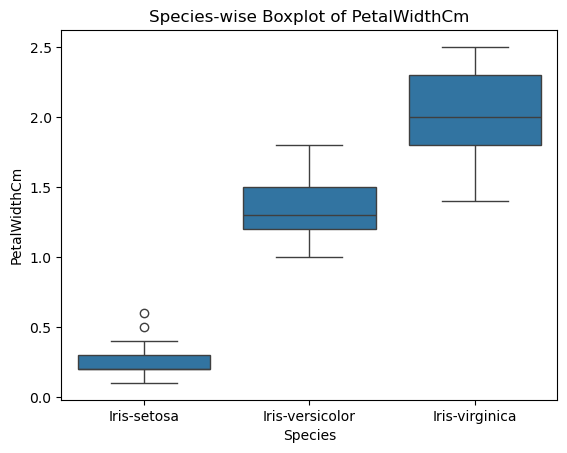

In [ ]:
import seaborn as sns
sns.boxplot(x='Species', y='PetalWidthCm', data=df)
plt.title('Species-wise Boxplot of PetalWidthCm')
plt.show()

C:\Users\comp542\AppData\Local\Temp\ipykernel_12640\2407488935.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


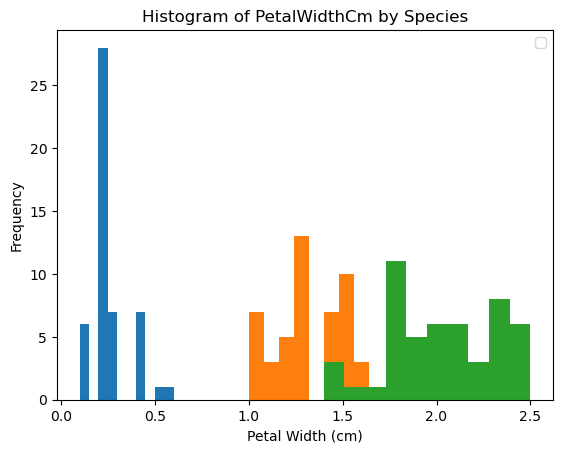

In [ ]:
for species in df['Species'].unique():
    species_data = df[df['Species'] == species]
    plt.hist(species_data['PetalWidthCm'], bins=10)

plt.title('Histogram of PetalWidthCm by Species')
plt.xlabel('Petal Width (cm)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
def find_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

In [ ]:
lower_bound

2.05

In [ ]:
upper_bound

4.05

In [ ]:
print("Pricing Outlier for each spexies for PetalWidthCm")
for species in df['Species'].unique():
    species_data = df[df['Species'] == species]['PetalWidthCm']
    outliers = find_outliers_iqr(species_data)
    print(f"Outliers for {species}:{outliers.values}")

Pricing Outlier for each spexies for PetalWidthCm
Outliers for Iris-setosa:[0.5 0.6]
Outliers for Iris-versicolor:[]
Outliers for Iris-virginica:[]


In [ ]:
def find_outlier_indices(df, species_name, column_name):
    species_data = df[df['Species'] == species_name][column_name]
    outliers = find_outliers_iqr(species_data)
    outlier_indices = outliers.index
    return outlier_indices
setosa_outlier_indices = find_outlier_indices(df, 'Iris-setosa', 'PetalWidthCm')
print(f"\nRow indices of outliers for Iris-setosa in 'PetalWidthCm': {setosa_outlier_indices.tolist()}")


Row indices of outliers for Iris-setosa in 'PetalWidthCm': [23, 43]
